# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

    A model is "linear" because the coefficients just get multiplied by their variables and added together. "Linear" refers to the parameters, not the data itself, so you can still log-transform your inputs or create interaction terms and it stays linear. As long as the weights enter the model in that multiply and add way it counts.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)

    A dummy variable is just a 0 or 1, so its coefficient tells you how much the predicted outcome shifts when that category is "on" compared to when it's "off." The trick is that you can't include a dummy for every category, you have to drop one, which becomes the baseline absorbed into the intercept. So the coefficient isn't some absolute value, it's always relative to that dropped category. If you included dummies for all categories you'd have perfect multicollinearity and the model breaks, which is called the dummy variable trap.

3. Can linear regression be used for classification? Explain why, or why not.

    Yes, you just regress on a 0/1 outcome and treat the predictions as probabilities, which is called the Linear Probability Model. The issue is nothing constrains the predictions to actually stay between 0 and 1, so you can get nonsensical outputs. It works fine when your data is well-behaved and you're not near the extremes, but otherwise people switch to logit or probit which are designed to keep predictions in bounds.

4. What are signs that your linear model is over-fitting?

    Signs that your model is over-fitting (doing great on training data but falling apart on test data) means that you've thrown in too many variables and the model is picking up on noise specific to your training set rather than actual patterns (memorizing, rather than learning).

5. Clearly explain multi-colinearity using the two-stage least squares technique.

    Multicollinearity is when two of your input variables are so correlated that the model can't tell which one is actually doing the work. Two-stage least squares gets around this by first regressing the problematic variable on an instrument- something correlated with that variable but not with the outcome directly- and using the predicted values from that regression in place of the original variable. That way you've stripped out the part of the variable that was tangled up with everything else, and what's left is clean enough for the model to actually learn from.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

    Even though linear models are linear in the parameters, nothing stops you from transforming the inputs before they go into the model. You can square a variable, take its log, or create interaction terms like multiplying two variables together the model is still linear because the coefficients are still just multiplying and adding. So you're essentially doing the nonlinear work upfront in feature engineering, then handing clean transformed variables to a model that stays linear under the hood.

7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

    The intercept is what the model predicts when every single variable is zero, which is often meaningless in practice but necessary for the model to fit properly. A slope coefficient tells you how much the predicted outcome changes for a one-unit increase in that variable, holding everything else constant. A dummy coefficient is the same idea but simpler, it's just the difference in predicted outcome between that category and the baseline category that got dropped.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.

                Price  Review Scores Rating
Neighbourhood                              
Manhattan      183.66                 91.80
Staten Island  146.17                 90.84
Brooklyn       127.75                 92.36
Queens          96.86                 91.55
Bronx           75.28                 91.65

Most expensive borough: Manhattan


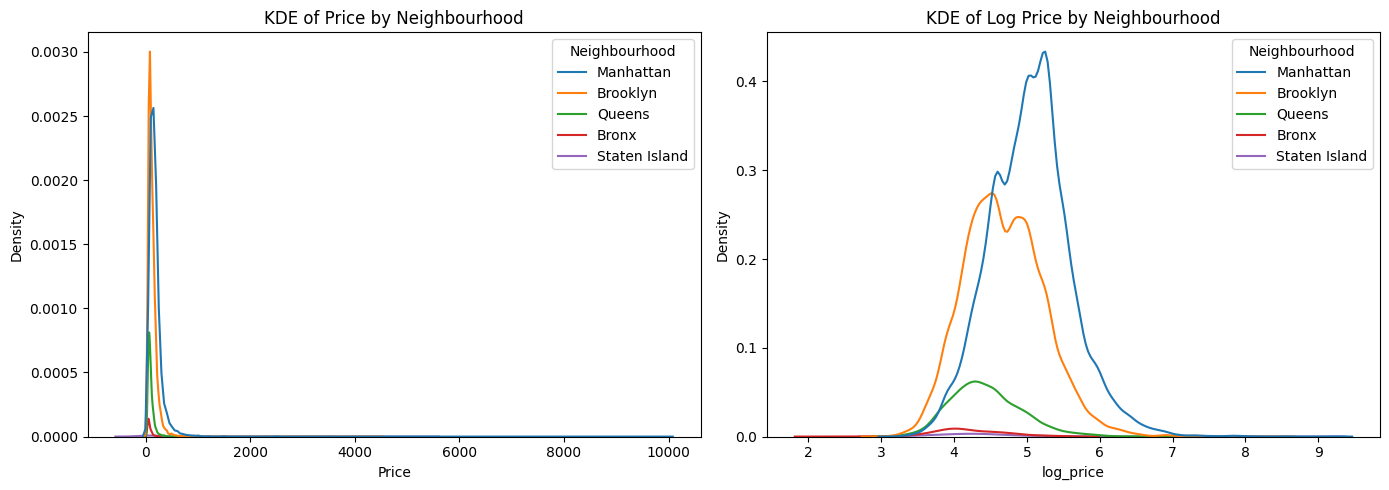

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('./data/Q1_clean.csv')
df = df.rename(columns={'Neighbourhood ': 'Neighbourhood'})

# Average price and scores by neighbourhood
summary = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean().round(2)
print(summary.sort_values('Price', ascending=False))
print(f"\nMost expensive borough: {summary['Price'].idxmax()}")

# KDE plots
df['log_price'] = np.log(df['Price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='Price', hue='Neighbourhood', ax=axes[0])
axes[0].set_title('KDE of Price by Neighbourhood')

sns.kdeplot(data=df, x='log_price', hue='Neighbourhood', ax=axes[1])
axes[1].set_title('KDE of Log Price by Neighbourhood')

plt.tight_layout()
plt.show()

2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

In [7]:
from sklearn.linear_model import LinearRegression

df = pd.read_csv('./data/Q1_clean.csv')
df = df.rename(columns={'Neighbourhood ': 'Neighbourhood'})

# One-hot encode neighbourhood, drop_first=False to keep all dummies (no intercept)
X = pd.get_dummies(df['Neighbourhood'], drop_first=False)
y = df['Price']

# Fit without intercept
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

# Display coefficients
coef_df = pd.DataFrame({
    'Neighbourhood': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df)

   Neighbourhood  Coefficient
2      Manhattan   183.664286
4  Staten Island   146.166667
1       Brooklyn   127.747378
3         Queens    96.857233
0          Bronx    75.276498


The coefficients will exactly match the group means from part 1, when you regress on dummies with no intercept, each coefficient just becomes the average price for that neighbourhood. The pattern is that coefficients on dummies without an intercept are just group means, and with an intercept the dropped category gets absorbed into the intercept and the rest become deviations from that baseline.

3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

In [9]:
# One-hot encode with drop_first=True to avoid dummy variable trap
X_intercept = pd.get_dummies(df['Neighbourhood'], drop_first=True)
y = df['Price']

model_intercept = LinearRegression(fit_intercept=True)
model_intercept.fit(X_intercept, y)

print(f"Intercept: {model_intercept.intercept_:.2f}")
print(f"Baseline (dropped) category: {pd.get_dummies(df['Neighbourhood']).columns[0]}")

coef_df2 = pd.DataFrame({
    'Neighbourhood': X_intercept.columns,
    'Coefficient': model_intercept.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df2)

Intercept: 75.28
Baseline (dropped) category: Bronx
   Neighbourhood  Coefficient
1      Manhattan   108.387789
3  Staten Island    70.890169
0       Brooklyn    52.470881
2         Queens    21.580735


With an intercept you have to drop one category (drop_first=True) to avoid the dummy variable trap. The intercept becomes the mean price of the dropped borough, and each coefficient is the difference in average price relative to that baseline. To get back to the part 2 coefficients (the group means), just add the intercept to each coefficient. That recovers the average price for each neighbourhood.

4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

y = df['Price']

# Model 1: Price ~ Review Scores Rating + Neighbourhood
X1 = pd.get_dummies(df[['Review Scores Rating', 'Neighbourhood']], drop_first=True)

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

model1 = LinearRegression(fit_intercept=True)
model1.fit(X1_train, y_train)

y_pred = model1.predict(X1_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")

coef_df = pd.DataFrame({'Feature': X1.columns, 'Coefficient': model1.coef_})
print(f"\nIntercept: {model1.intercept_:.2f}")
print(coef_df)

#Model 2: Price ~ Review Scores Rating + Neighbourhood + Property Type
X2 = pd.get_dummies(df[['Review Scores Rating', 'Neighbourhood', 'Property Type']], drop_first=True)

X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression(fit_intercept=True)
model2.fit(X2_train, y_train)

prop_coefs = pd.DataFrame({'Feature': X2.columns, 'Coefficient': model2.coef_})
prop_coefs = prop_coefs[prop_coefs['Feature'].str.startswith('Property Type')]
print(f"\nMost expensive property type: {prop_coefs.loc[prop_coefs['Coefficient'].idxmax(), 'Feature']}")

R²:   0.0459
RMSE: 140.92

Intercept: -35.16
                       Feature  Coefficient
0         Review Scores Rating     1.211852
1       Neighbourhood_Brooklyn    51.555970
2      Neighbourhood_Manhattan   107.413553
3         Neighbourhood_Queens    20.198573
4  Neighbourhood_Staten Island    23.454672

Most expensive property type: Property Type_Bungalow


5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [11]:
X = pd.get_dummies(df[['Review Scores Rating', 'Neighbourhood', 'Property Type']], drop_first=True)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(f"\nIntercept: {model.intercept_:.2f}")

rating_coef = coef_df[coef_df['Feature'] == 'Review Scores Rating']['Coefficient'].values[0]
print(f"\nCoefficient on Review Scores Rating: {rating_coef:.4f}")

prop_coefs = coef_df[coef_df['Feature'].str.startswith('Property Type')]
print(f"\nMost expensive property type: {prop_coefs.loc[prop_coefs['Coefficient'].idxmax(), 'Feature']}")

R²:   0.0542
RMSE: 140.30

Intercept: -49.30

Coefficient on Review Scores Rating: 1.2010

Most expensive property type: Property Type_Bungalow


6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.

    When you add Property Type to the model, the coefficient on Review Scores Rating changes because multiple regression isolates the effect of each variable after controlling for everything else. If the coefficient shifts, it means Review Scores Rating and Property Type are correlated, since certain property types tend to have higher or lower ratings on average. So in part 4, the rating coefficient was partially picking up the effect of property type without realizing it. Once you add property type in part 5, the coefficient on rating reflects only the pure relationship between rating and price, holding property type fixed.

7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [12]:
# Create interaction term between Property Type and Neighbourhood
df['PropXNeighbourhood'] = df['Property Type'] + ' in ' + df['Neighbourhood']

X = pd.get_dummies(df[['Review Scores Rating', 'PropXNeighbourhood']], drop_first=True)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")

rating_coef = model.coef_[0]
print(f"\nCoefficient on Review Scores Rating: {rating_coef:.4f}")

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
prop_coefs = coef_df[coef_df['Feature'].str.startswith('PropXNeighbourhood') == False]

interaction_coefs = coef_df[coef_df['Feature'] != 'Review Scores Rating']
print(f"\nMost expensive combo: {interaction_coefs.loc[interaction_coefs['Coefficient'].idxmax(), 'Feature']}")
print(f"\nIntercept: {model.intercept_:.2f}")

R²:   0.0546
RMSE: 140.28

Coefficient on Review Scores Rating: 1.1990

Most expensive combo: PropXNeighbourhood_Loft in Manhattan

Intercept: -34.06


The interaction coefficients are NOT just the sum of the separate neighbourhood and property type coefficients from part 5, they're estimated independently, so they capture the specific combination's effect directly. The R^2 should tick up slightly and RMSE down since the model is more flexible, but probably not dramatically since most of the variation was already captured by the separate dummies.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.

In [13]:
df = pd.read_csv('./data/cars_hw.csv')

print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())

(976, 12)
Unnamed: 0           int64
Make                   str
Make_Year            int64
Color                  str
Body_Type              str
Mileage_Run          int64
No_of_Owners           str
Seating_Capacity     int64
Fuel_Type              str
Transmission           str
Transmission_Type      str
Price                int64
dtype: object
       Unnamed: 0    Make_Year   Mileage_Run  Seating_Capacity         Price
count  976.000000   976.000000    976.000000        976.000000  9.760000e+02
mean   488.500000  2016.963115  41571.195697          5.095287  7.410195e+05
std    281.891232     2.818742  24390.995134          0.446224  3.673234e+05
min      1.000000  2011.000000   1117.000000          4.000000  1.880000e+05
25%    244.750000  2015.000000  22676.750000          5.000000  4.757500e+05
50%    488.500000  2017.000000  37570.500000          5.000000  6.665000e+05
75%    732.250000  2019.000000  57421.250000          5.000000  8.830000e+05
max    976.000000  2022.000000  9949

 2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


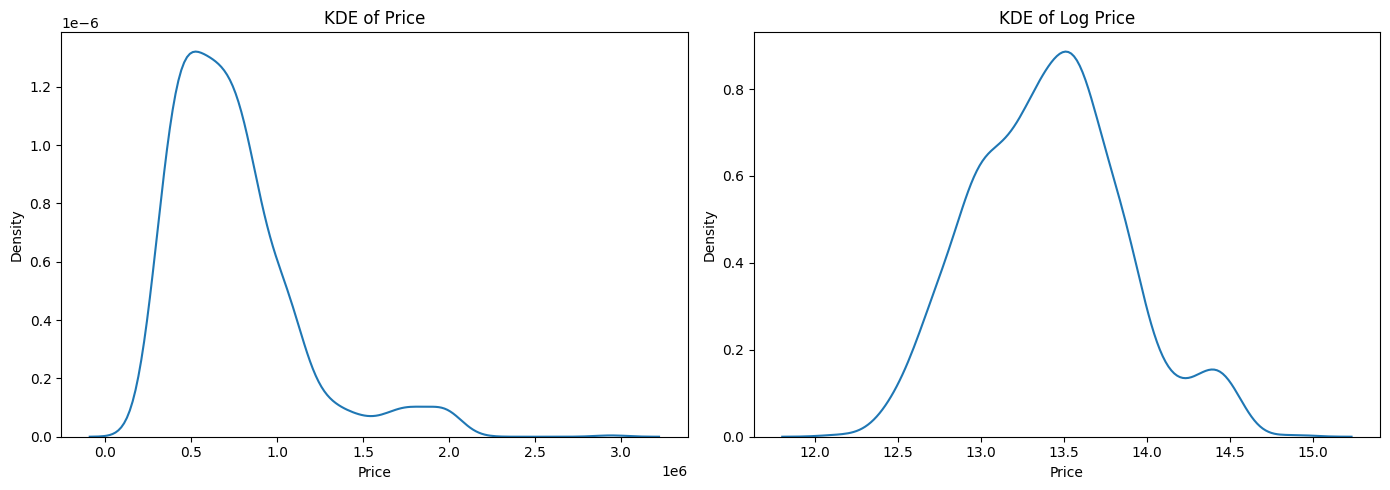

               count          mean           std        min        25%  \
Make                                                                     
MG Motors       35.0  1.869457e+06  1.216611e+05  1589000.0  1786500.0   
Kia              8.0  1.614750e+06  1.190567e+05  1369000.0  1579000.0   
Jeep             4.0  1.499500e+06  1.525134e+05  1290000.0  1447500.0   
Skoda            5.0  1.136000e+06  1.070175e+06   436000.0   466000.0   
Mahindra        18.0  1.100167e+06  1.755493e+05   796000.0  1037000.0   
Tata            23.0  1.055217e+06  5.578305e+05   188000.0   779500.0   
Nissan           4.0  8.842500e+05  2.895599e+05   475000.0   782500.0   
Toyota          50.0  8.003400e+05  2.466900e+05   368000.0   526250.0   
Honda           73.0  7.989726e+05  2.665091e+05   316000.0   581000.0   
Ford            52.0  7.211731e+05  1.409277e+05   290000.0   635000.0   
Hyundai        305.0  6.918918e+05  2.791597e+05   248000.0   485000.0   
Renault         68.0  6.625735e+05  2.

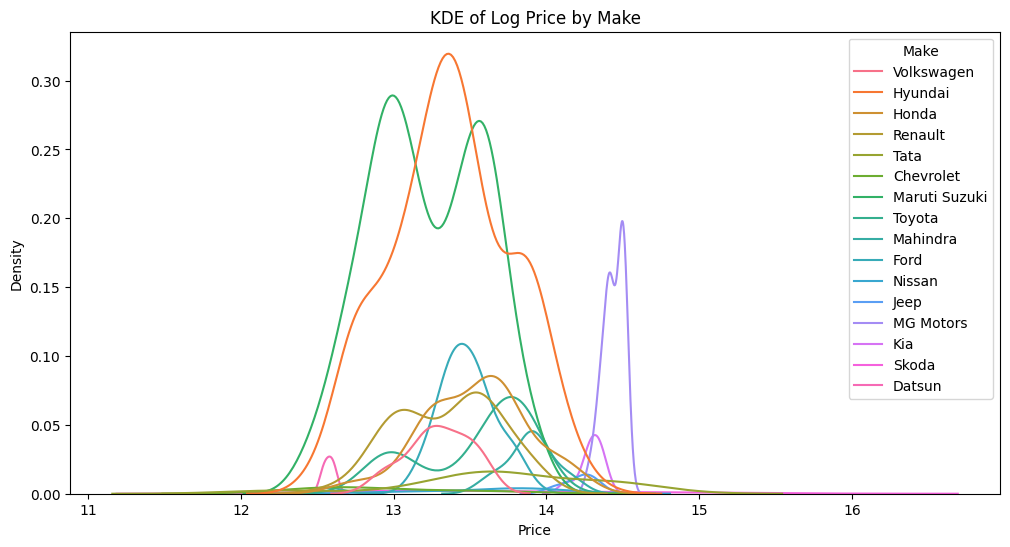

In [14]:
# Overall price summary
print(df['Price'].describe())

# KDE of price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(df['Price'], ax=axes[0])
axes[0].set_title('KDE of Price')

sns.kdeplot(np.log(df['Price']), ax=axes[1])
axes[1].set_title('KDE of Log Price')

plt.tight_layout()
plt.show()

# Summary by Make
print(df.groupby('Make')['Price'].describe().sort_values('mean', ascending=False))

# Grouped KDE by Make
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x=np.log(df['Price']), hue='Make')
plt.title('KDE of Log Price by Make')
plt.show()

 3. Split the data into an 80% training set and a 20% testing set.

In [19]:
X = df.drop(columns='Price')
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} rows")
print(f"Test:  {X_test.shape[0]} rows")

Train: 780 rows
Test:  196 rows


4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

In [22]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    train_pred = model.predict(X_tr)
    test_pred  = model.predict(X_te)
    print(f"  Train R²: {r2_score(y_tr, train_pred):.4f} | Train RMSE: {root_mean_squared_error(y_tr, train_pred):.2f}")
    print(f"  Test  R²: {r2_score(y_te, test_pred):.4f} | Test  RMSE: {root_mean_squared_error(y_te, test_pred):.2f}")

# Model 1: Numeric only
num_cols = X_train.select_dtypes(include='number').columns.tolist()
print("Model 1: Numeric only")
evaluate(LinearRegression(), X_train[num_cols], X_test[num_cols], y_train, y_test)

# Model 2: Categorical only (one-hot encoded)
cat_cols = X_train.select_dtypes(include=['object', 'str']).columns.tolist()
X_cat_train = pd.get_dummies(X_train[cat_cols], drop_first=True)
X_cat_test  = pd.get_dummies(X_test[cat_cols],  drop_first=True)
X_cat_train, X_cat_test = X_cat_train.align(X_cat_test, join='left', axis=1, fill_value=0)
print("\nModel 2: Categorical only")
evaluate(LinearRegression(), X_cat_train, X_cat_test, y_train, y_test)

# Model 3: Combined
X_combined_train = pd.concat([X_train[num_cols], X_cat_train], axis=1)
X_combined_test  = pd.concat([X_test[num_cols],  X_cat_test],  axis=1)
print("\nModel 3: Combined")
evaluate(LinearRegression(), X_combined_train, X_combined_test, y_train, y_test)

Model 1: Numeric only
  Train R²: 0.3175 | Train RMSE: 308652.10
  Test  R²: 0.2909 | Test  RMSE: 285188.67

Model 2: Categorical only
  Train R²: 0.7736 | Train RMSE: 177763.32
  Test  R²: 0.7087 | Test  RMSE: 182791.11

Model 3: Combined
  Train R²: 0.8573 | Train RMSE: 141148.29
  Test  R²: 0.8164 | Test  RMSE: 145117.59


Categorical is better than numeric. Brand, body type, and transmission explain way more of the price variation than mileage or seating capacity. The combined model is the best, jumping from 0.71 to 0.82 R² and cutting RMSE by about 37k compared to categorical alone, so the numeric variables do add meaningful signal on top of the categoricals even if they're weak on their own.

 5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

In [25]:
from sklearn.preprocessing import PolynomialFeatures

results = []

for degree in range(1, 6):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    
    X_poly_train = poly.fit_transform(X_train[num_cols])
    X_poly_test  = poly.transform(X_test[num_cols])
    
    model = LinearRegression()
    model.fit(X_poly_train, y_train)
    
    train_r2   = r2_score(y_train, model.predict(X_poly_train))
    test_r2    = r2_score(y_test,  model.predict(X_poly_test))
    test_rmse  = root_mean_squared_error(y_test, model.predict(X_poly_test))
    
    results.append({'Degree': degree, 'Train R²': train_r2, 'Test R²': test_r2, 'Test RMSE': test_rmse})
    print(f"Degree {degree}: Train R²={train_r2:.4f} | Test R²={test_r2:.4f} | Test RMSE={test_rmse:.2f}")

# Best degree by test R^2
results_df = pd.DataFrame(results)
best_degree = results_df.loc[results_df['Test R²'].idxmax(), 'Degree']
print(f"\nBest degree: {best_degree}")

Degree 1: Train R²=0.3175 | Test R²=0.2909 | Test RMSE=285188.67
Degree 2: Train R²=0.3524 | Test R²=0.3050 | Test RMSE=282330.75
Degree 3: Train R²=0.3593 | Test R²=0.3259 | Test RMSE=278048.91
Degree 4: Train R²=0.3765 | Test R²=0.2652 | Test RMSE=290315.51
Degree 5: Train R²=0.3865 | Test R²=0.3338 | Test RMSE=276420.24

Best degree: 5


Train R^2 creeps up steadily with each degree as expected, but test R^2 bounces around and never really takes off, it actually dips at degree 4 before recovering at 5. It never goes negative here, which means the numeric variables just don't have enough polynomial signal to catastrophically overfit at these degrees.

The best polynomial model (degree 5) gets R&2 = 0.33 and RMSE = 276k, which is still way worse than the categorical-only model from part 4 (R^2 = 0.71, RMSE = 182k). So expanding the numeric features polynomially doesn't get you anywhere close to just knowing the brand and body type of the car.

 6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

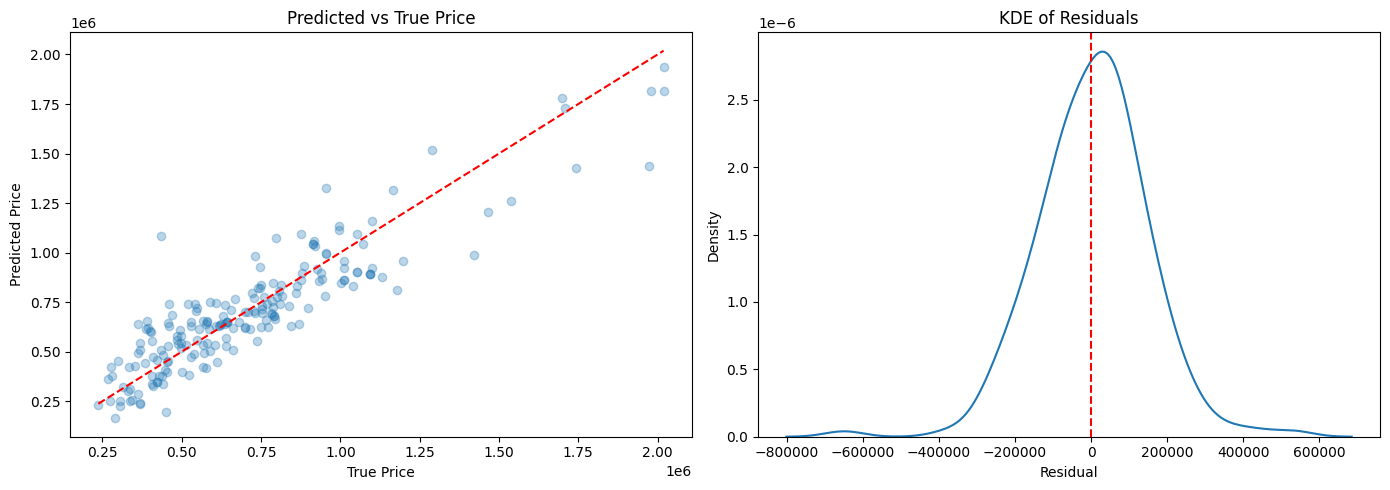

Mean residual: 5053.20
Std residual:  145400.98


In [26]:
# Best model is Model 3 (combined numeric + categorical)
model3 = LinearRegression()
model3.fit(X_combined_train, y_train)
y_pred = model3.predict(X_combined_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('True Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Predicted vs True Price')

# Residual KDE
sns.kdeplot(residuals, ax=axes[1])
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_title('KDE of Residuals')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std residual:  {residuals.std():.2f}")

The predicted vs true plot looks good. Points track along the diagonal reasonably well across the price range, which means the model is capturing the general trend. It does spread out more at higher prices though, suggesting it's less precise for expensive cars.
The residuals are not quite bell-shaped, they're noticeably right-skewed with a longer tail on the positive side, meaning the model tends to underpredict high-priced cars more than it overpredicts low-priced ones. The mean residual of ~5k is close to zero which is good, but the std of 145k is huge relative to typical car prices.

Some strengths: decent overall fit (R^2 = 0.82), tracks the diagonal well for mid-range cars, categorical variables do a lot of heavy lifting.

Some weaknesses: residuals aren't symmetric so the model systematically underpredicts luxury/expensive cars, and that 145k std on residuals is pretty rough in absolute terms. Log-transforming price as the outcome would likely fix a lot of this since it would compress the right tail and make the residuals more symmetric.

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is 
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
    
    Question 1 in Q4 folder.

2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
    
    Question 2 in Q4 folder.

3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
    
    Question 3 in Q4 folder.

4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.

    Question 4 in Q4 folder.

5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.

    Question 5 in Q4 folder.


6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

    Question 6 (divide both sides into normal equations) in Q4 folder.
    Additionaly, A is the covariance matrix of the features, it captures how much each variable varies on its own and how correlated they are with each other. C is the vector of covariances between each feature and the outcome.

    The intuition is that the OLS is asking "how much does each feature co-move with y, after accounting for how the features co-move with each other?" The A matrix is what forces the model to account for relationships between features, which is exactly what separates multiple regression from just running two separate simple regressions. If x_1 and x_2 were completely uncorrelated, A would be diagonal and the coefficients would reduce to two independent simple regressions.